# Daten einlesen und ersten Überblick bekommen 

In [1]:
import pandas as pd
import os

base_path = "/datasets/multi-view-pig-posture-recognition"

# Laden der Trainingsdaten
train1_df = pd.read_csv(os.path.join(base_path, 'train1.csv'))
train2_df = pd.read_csv(os.path.join(base_path, 'train2.csv'))

train_df = pd.concat([train1_df, train2_df], ignore_index=True)

print(train_df.head())

<jemalloc>: Unsupported system page size


                                     row_id  \
0  train_pen1_orb_cam1_20250108_085204_0000   
1  train_pen1_orb_cam1_20250108_085204_0001   
2  train_pen1_orb_cam1_20250108_085204_0002   
3  train_pen1_orb_cam1_20250108_085204_0003   
4  train_pen1_orb_cam1_20250108_085204_0004   

                            image_id  width  height  \
0  pen1_orb_cam1_20250108_085204.jpg   1920    1080   
1  pen1_orb_cam1_20250108_085204.jpg   1920    1080   
2  pen1_orb_cam1_20250108_085204.jpg   1920    1080   
3  pen1_orb_cam1_20250108_085204.jpg   1920    1080   
4  pen1_orb_cam1_20250108_085204.jpg   1920    1080   

                         bbox  class_id  
0  [1031.5,368.0,349.0,435.0]         0  
1  [1278.5,428.0,233.0,438.0]         4  
2   [732.0,137.5,342.0,198.0]         1  
3   [830.0,169.0,370.0,263.0]         0  
4   [611.5,314.8,381.5,386.6]         3  


In [2]:
# Zeigt alle Spaltennamen an
print("Spalten im Dataframe:", train_df.columns.tolist())

print("\nInhalt der ersten Zeile:")
print(train_df.iloc[0])

Spalten im Dataframe: ['row_id', 'image_id', 'width', 'height', 'bbox', 'class_id']

Inhalt der ersten Zeile:
row_id      train_pen1_orb_cam1_20250108_085204_0000
image_id           pen1_orb_cam1_20250108_085204.jpg
width                                           1920
height                                          1080
bbox                      [1031.5,368.0,349.0,435.0]
class_id                                           0
Name: 0, dtype: object


In [3]:
train1_df.head()

,row_id,image_id,width,height,bbox,class_id
0,train_pen1_orb_cam1_20250108_085204_0000,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1031.5,368.0,349.0,435.0]",0
1,train_pen1_orb_cam1_20250108_085204_0001,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1278.5,428.0,233.0,438.0]",4
2,train_pen1_orb_cam1_20250108_085204_0002,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[732.0,137.5,342.0,198.0]",1
3,train_pen1_orb_cam1_20250108_085204_0003,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[830.0,169.0,370.0,263.0]",0
4,train_pen1_orb_cam1_20250108_085204_0004,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[611.5,314.8,381.5,386.6]",3


In [4]:
train2_df.head()

,row_id,image_id,width,height,bbox,class_id
0,train_pen1_orb_cam1_20250108_085204_0000,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1031.5,368.0,349.0,435.0]",0
1,train_pen1_orb_cam1_20250108_085204_0001,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1278.5,428.0,233.0,438.0]",4
2,train_pen1_orb_cam1_20250108_085204_0002,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[732.0,137.5,342.0,198.0]",1
3,train_pen1_orb_cam1_20250108_085204_0003,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[830.0,169.0,370.0,263.0]",0
4,train_pen1_orb_cam1_20250108_085204_0004,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[611.5,314.8,381.5,386.6]",3


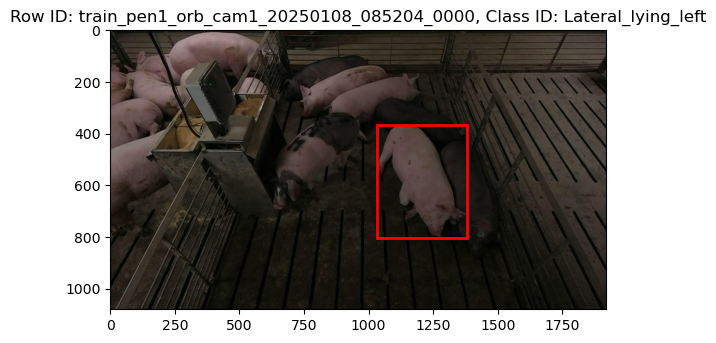

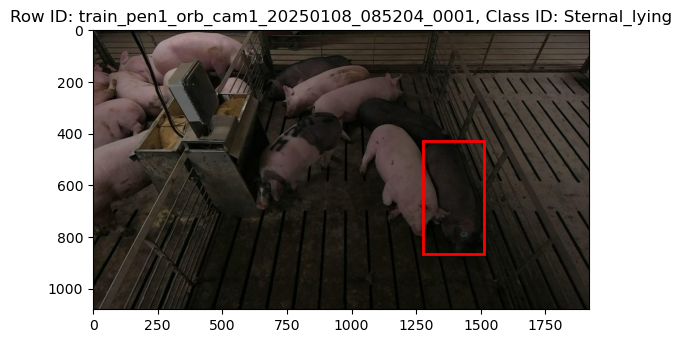

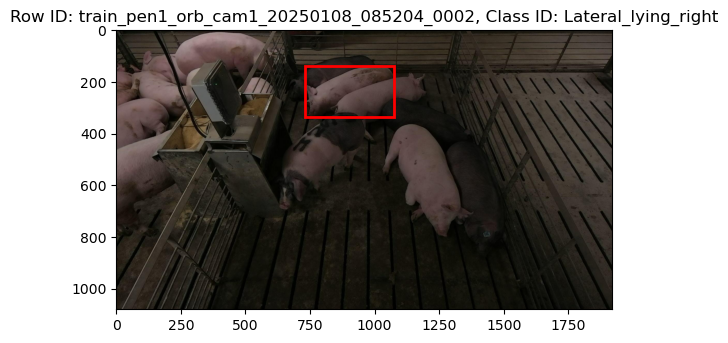

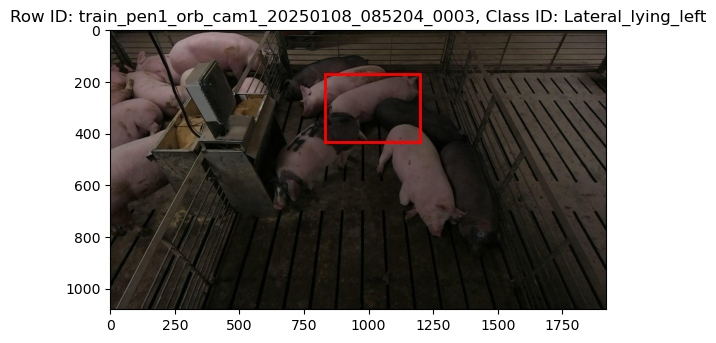

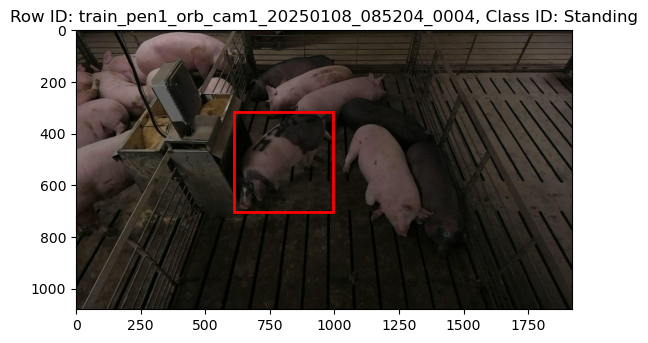

In [5]:
# data paths
train1_path = "/datasets/multi-view-pig-posture-recognition/train1_images"
train2_path = "/datasets/multi-view-pig-posture-recognition/train2_images"
test_path = "/datasets/multi-view-pig-posture-recognition/test_images"
# csv path with row_id, image_id, width, height, bbox, class_id
train1_csv = "/datasets/multi-view-pig-posture-recognition/train1.csv"
train2_csv = "/datasets/multi-view-pig-posture-recognition/train2.csv"
test_csv = "/datasets/multi-view-pig-posture-recognition/test.csv"
# pig posture classes
pig_posture_classes = {
    0: "Lateral_lying_left",
    1: "Lateral_lying_right",
    2: "Sitting",
    3: "Standing",
    4: "Sternal_lying"
}

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
train1 = pd.read_csv(train1_csv)
train2 = pd.read_csv(train2_csv)
test = pd.read_csv(test_csv)
#show the first 5 rows of train1 paired with their images and their bboxes drawn on the images
for i in range(5):
    row = train1.iloc[i]
    image_id = row["image_id"]
    image_path = f"{train1_path}/{image_id}"
    image = Image.open(image_path)
    plt.imshow(image)
    plt.title(f"Row ID: {row['row_id']}, Class ID: {pig_posture_classes[row['class_id']]}")
    # draw the bbox on the image
    bbox = eval(row["bbox"])
    x, y, w, h = bbox
    plt.gca().add_patch(plt.Rectangle((x, y), w, h, fill=False, edgecolor='red', linewidth=2))
    plt.show()

# EDA vom Projekt

In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

BASE_PATH = "/datasets/multi-view-pig-posture-recognition"

# Beide CSVs laden
df1 = pd.read_csv(os.path.join(BASE_PATH, "train1.csv"))
df2 = pd.read_csv(os.path.join(BASE_PATH, "train2.csv"))

# Pfade zu den jeweiligen Ordnern ergänzen
df1['full_path'] = df1['image_id'].apply(lambda x: os.path.join(BASE_PATH, "train1_images", x))
df2['full_path'] = df2['image_id'].apply(lambda x: os.path.join(BASE_PATH, "train2_images", x))

# Zusammenführen zu einem großen DataFrame
df = pd.concat([df1, df2], ignore_index=True)

print(f"Gesamtanzahl Datensätze: {len(df)}")
print(f"Bilder in Set 1: {len(df1)} | Bilder in Set 2: {len(df2)}")

Gesamtanzahl Datensätze: 46384
Bilder in Set 1: 22934 | Bilder in Set 2: 23450


In [7]:
with open(os.path.join(BASE_PATH, "pig_posture_classes.txt"), "r") as f:
    print("Klassen-Definitionen:")
    print(f.read())

Klassen-Definitionen:
Lateral_lying_left
Lateral_lying_right
Sitting
Standing
Sternal_lying



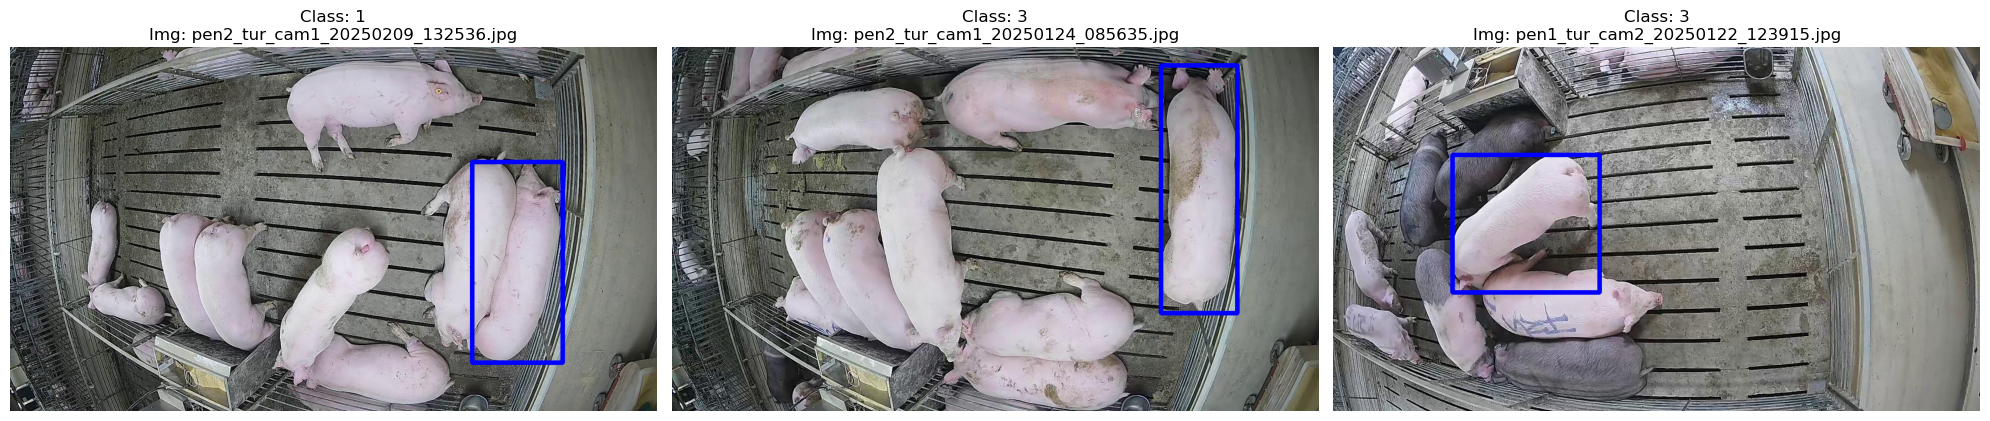

In [8]:
import ast
import matplotlib.pyplot as plt
import cv2

def plot_multi_view_samples_final_red(df, n=3):
    sample = df.sample(n)
    fig, axes = plt.subplots(1, n, figsize=(20, 10))
    
    # Falls nur 1 Bild angefragt wird, axes als Liste behandeln
    if n == 1: axes = [axes]

    for i, (idx, row) in enumerate(sample.iterrows()):
        # Bild laden (Pfad wurde in Schritt 1 erstellt)
        img = cv2.imread(row['full_path'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Bbox konvertieren: aus "[x, y, w, h]" wird [x, y, w, h]
        bbox = row['bbox']
        if isinstance(bbox, str):
            bbox = ast.literal_eval(bbox)
        
        x, y, w, h = bbox
        
        # Zeichnen: Startpunkt (x,y) und Endpunkt (x+w, y+h)
        cv2.rectangle(img, (int(x), int(y)), 
                      (int(x + w), int(y + h)), (0, 0, 255), 8)
        
        axes[i].imshow(img)
        axes[i].set_title(f"Class: {row['class_id']}\nImg: {row['image_id']}")
        axes[i].axis('off')
        
    plt.tight_layout()
    plt.show()

# Funktion aufrufen
plot_multi_view_samples_final_red(df, n=3)

/tmp/ipykernel_3797/2300978649.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='class_id', y='bbox_area', ax=ax[1], palette='viridis')


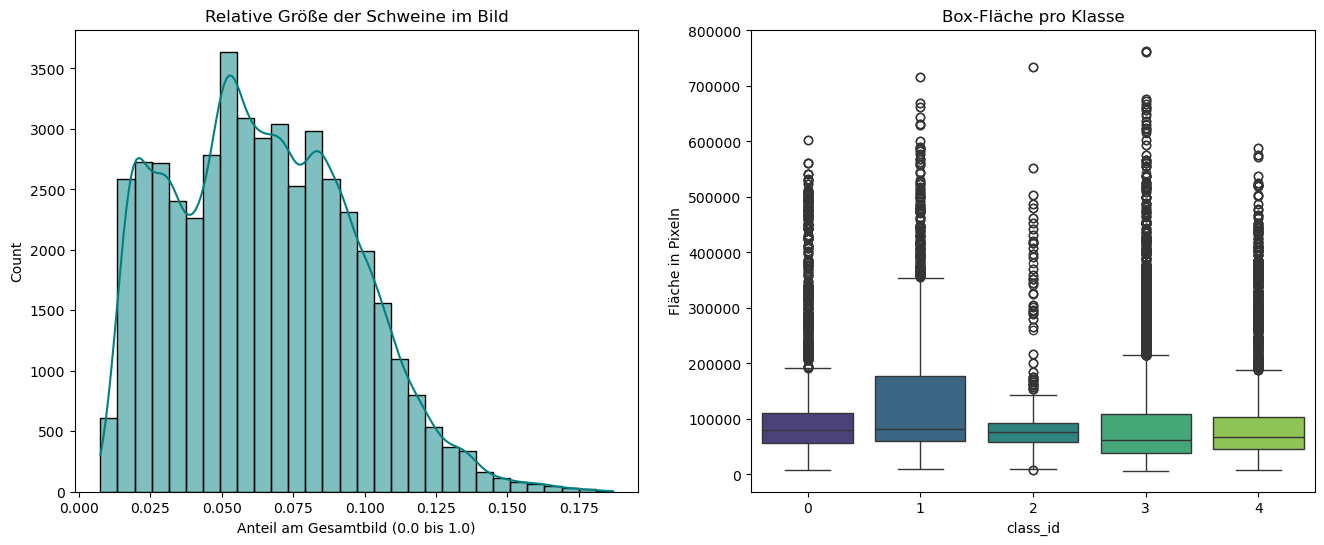

Durchschnittliche Box-Fläche: 94852 Pixel


In [9]:
# Hilfsspalten für die Analyse berechnen
def get_bbox_area(bbox):
    if isinstance(bbox, str):
        bbox = ast.literal_eval(bbox)
    return bbox[2] * bbox[3] # width * height

df['bbox_area'] = df['bbox'].apply(get_bbox_area)
df['img_area'] = df['width'] * df['height']
df['relative_size'] = df['bbox_area'] / df['img_area']

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# 1. Verteilung der relativen Größe (Wie viel % vom Bild nimmt das Schwein ein?)
sns.histplot(df['relative_size'], bins=30, kde=True, ax=ax[0], color='teal')
ax[0].set_title('Relative Größe der Schweine im Bild')
ax[0].set_xlabel('Anteil am Gesamtbild (0.0 bis 1.0)')

# 2. Box-Größe vs. Klasse (Sind liegende Schweine "größer" als stehende?)
sns.boxplot(data=df, x='class_id', y='bbox_area', ax=ax[1], palette='viridis')
ax[1].set_title('Box-Fläche pro Klasse')
ax[1].set_ylabel('Fläche in Pixeln')

plt.show()

print(f"Durchschnittliche Box-Fläche: {df['bbox_area'].mean():.0f} Pixel")

# Zusammenfassung der EDA-Ergebnisse

##### Relative Größe: Die Schweine belegen meist nur 2,5 % bis 10 % des Bildes. Der hohe Hintergrundanteil macht Ausschneiden der Boxen für das Modell-Training sinnvoll.Klassenunterschiede: Klasse 1 hat tendenziell die größten Bounding Boxes (vermutlich liegende Position), während die anderen Klassen kompakter sind.Bildqualität: Mit durchschnittlich ~95.000 Pixeln pro Box ist die Auflösung hoch genug für gängige Netze wie ResNet oder EfficientNet.Ausreißer: Die vielen Punkte in der Boxplot-Grafik zeigen, dass Tiere in unterschiedlichen Distanzen zur Kamera stehen, was das Modell robust gegenüber Skalierung machen muss.

# Cropping & Dataset-Erstellung

##### Da die EDA gezeigt hat, dass die Schweine nur einen kleinen Teil des Bildes einnehmen, schneiden wir die Bilder auf die Bounding Boxes zu. Dies reduziert das Hintergrundrauschen und hilft dem Modell, sich auf die Körperhaltung zu konzentrieren. Wir fügen einen kleinen Puffer hinzu, um sicherzustellen, dass keine Hufe oder Ohren am Rand abgeschnitten werden. Da der vollständige Datensatz sehr groß ist, erstellen wir für die erste Modellentwicklung ein repräsentatives Subsample von 10.000 Bildern.

In [10]:
import os
import cv2
import ast
import pandas as pd
from tqdm import tqdm

#  Zielverzeichnis erstellen
crop_dir = "cropped_pigs"
os.makedirs(crop_dir, exist_ok=True)

# Repräsentatives Subsample von 10.000 Bildern erstellen
# nutzen von groupby, um die Klassenverteilung (0-4) exakt beizubehalten
sample_size = 10000
df_subset = df.groupby('class_id', group_keys=False).apply(
    lambda x: x.sample(n=int(len(x)/len(df) * sample_size), random_state=42)
).reset_index(drop=True)

print(f"Subsampling abgeschlossen: {len(df_subset)} Bilder ausgewählt.")

# Cropping Funktion (nur für die 10.000 Bilder)
def save_cropped_images(df_sub, output_path, padding=10):
    new_data = []
    for i, row in tqdm(df_sub.iterrows(), total=len(df_sub), desc="Cropping läuft"):
        img = cv2.imread(row['full_path'])
        if img is None: continue
        
        # Bbox extrahieren [x, y, w, h]
        bbox = row['bbox']
        if isinstance(bbox, str): bbox = ast.literal_eval(bbox)
        x, y, w, h = [int(v) for v in bbox]
        
        # Padding berechnen (Rand um das Schwein)
        img_h, img_w, _ = img.shape
        y1, y2 = max(0, y - padding), min(img_h, y + h + padding)
        x1, x2 = max(0, x - padding), min(img_w, x + w + padding)
        
        # Crop erstellen und speichern
        crop = img[y1:y2, x1:x2]
        filename = f"crop_{i}_{row['image_id']}"
        cv2.imwrite(os.path.join(output_path, filename), crop)
        
        new_data.append({
            'filename': filename,
            'class_id': row['class_id'],
            'original_id': row['image_id']
        })
    return pd.DataFrame(new_data)

# Ausführung des Croppings
cropped_df = save_cropped_images(df_subset, crop_dir)
cropped_df.to_csv("train_cropped_subset.csv", index=False)
print(f"Fertig! {len(cropped_df)} Bilder in '{crop_dir}' gespeichert.")

/tmp/ipykernel_3797/3821186848.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_subset = df.groupby('class_id', group_keys=False).apply(


Subsampling abgeschlossen: 9997 Bilder ausgewählt.


Cropping läuft: 100%|██████████| 9997/9997 [03:28<00:00, 47.85it/s]


Fertig! 9997 Bilder in 'cropped_pigs' gespeichert.


# Modell-Vorbereitung: Dataset & Transformationen

##### Um die Bilder in das neuronale Netz zu packen, müssen wir sie standardisieren. Da die Schweine-Crops unterschiedliche Größen haben, skalieren wir alle auf 224x224 Pixel.

In [11]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from PIL import Image

# Daten in Training und Validierung aufteilen (80/20 Split)
train_data, val_data = train_test_split(cropped_df, test_size=0.2, stratify=cropped_df['class_id'], random_state=42)

# Transformationen definieren (Größe anpassen & Augmentation)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5), # Schwein kann links oder rechts schauen
    transforms.RandomRotation(15),           # Schweine liegen oft schräg
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet Standards
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Eigene Dataset-Klasse erstellen
class PigDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.df = dataframe
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.df.iloc[idx]['filename'])
        image = Image.open(img_path).convert("RGB")
        label = self.df.iloc[idx]['class_id']
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

# DataLoader erstellen (Laden der Daten in "Batches")
train_loader = DataLoader(PigDataset(train_data, "cropped_pigs", train_transforms), batch_size=32, shuffle=True)
val_loader = DataLoader(PigDataset(val_data, "cropped_pigs", val_transforms), batch_size=32, shuffle=False)

print(f"DataLoader bereit: {len(train_loader)} Batches für Training, {len(val_loader)} für Validierung.")

DataLoader bereit: 250 Batches für Training, 63 für Validierung.


# Trainingsmodell

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from tqdm import tqdm

# Gerät festlegen (GPU oder CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Modell wird trainiert auf: {device}")

# ResNet18 Modell laden & anpassen
model = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 5) # 5 Klassen für die Schweine-Haltung
model = model.to(device)

# Verlustfunktion und Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Trainings-Schleife
num_epochs = 5

for epoch in range(num_epochs):
    # TRAININGSPHASE
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(train_loader, desc=f"Epoche {epoch+1}/{num_epochs} [Train]"):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    train_acc = 100. * correct / total
    train_loss = running_loss / len(train_loader.dataset)
    
    # VALIDIERUNGSPHASE
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
            
    val_acc = 100. * val_correct / val_total
    v_loss = val_loss / len(val_loader.dataset)
    
    print(f"Epoche {epoch+1}: Train-Loss: {train_loss:.4f} | Train-Acc: {train_acc:.2f}%")
    print(f"          Val-Loss: {v_loss:.4f} | Val-Acc: {val_acc:.2f}%")

print("Training abgeschlossen!")

Modell wird trainiert auf: cuda


Epoche 1/5 [Train]: 100%|██████████| 250/250 [05:01<00:00,  1.21s/it]


Epoche 1: Train-Loss: 0.9596 | Train-Acc: 63.20%
          Val-Loss: 0.8769 | Val-Acc: 67.00%


Epoche 2/5 [Train]: 100%|██████████| 250/250 [05:09<00:00,  1.24s/it]


Epoche 2: Train-Loss: 0.7023 | Train-Acc: 73.93%
          Val-Loss: 1.3264 | Val-Acc: 59.35%


...

Epoche 3: Train-Loss: 0.5846 | Train-Acc: 78.59%
          Val-Loss: 0.6073 | Val-Acc: 78.60%


Epoche 4/5 [Train]: 100%|██████████| 250/250 [05:01<00:00,  1.21s/it]


Epoche 4: Train-Loss: 0.5229 | Train-Acc: 80.52%
          Val-Loss: 0.6374 | Val-Acc: 77.60%


Epoche 5/5 [Train]: 100%|██████████| 250/250 [05:03<00:00,  1.21s/it]


Epoche 5: Train-Loss: 0.4350 | Train-Acc: 84.24%
          Val-Loss: 0.7272 | Val-Acc: 74.55%
Training abgeschlossen!
